In [16]:
# QRISK3 Calculator - Session 1
# Let's collect some patient information

print("=== QRISK3 Cardiovascular Risk Calculator ===")
print()

# Patient inputs
age = int(input("Age: "))
systolic_bp = float(input("Systolic BP (mmHg): "))
total_cholesterol = float(input("Total cholesterol (mmol/L): "))
hdl_cholesterol = float(input("HDL cholesterol (mmol/L): "))
smoker = input("Smoker? (never/ex/light/moderate/heavy): ").lower()
diabetic = input("Type 2 diabetes? (yes/no): ").lower()
sex = input("Sex (male/female): ").lower()

# Calculate cholesterol ratio
chol_ratio = total_cholesterol / hdl_cholesterol

print()
print(f"--- Summary ---")
print(f"Patient: {sex}, age {age}")
print(f"BP: {systolic_bp} mmHg")
print(f"Cholesterol ratio: {chol_ratio:.1f}")
print(f"Smoker: {smoker} | Diabetic: {diabetic}")
print()
print("✓ Inputs collected. Risk calculation coming in Session 2!")

=== QRISK3 Cardiovascular Risk Calculator ===


--- Summary ---
Patient: male, age 50
BP: 120.0 mmHg
Cholesterol ratio: 1.2
Smoker: moderate | Diabetic: yes

✓ Inputs collected. Risk calculation coming in Session 2!


In [17]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('patients.csv')

# Have a look at it
print(df)
print()
print(f"Loaded {len(df)} patients")
print()
print("Column names:", df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

  patient_id  age     sex  systolic_bp  total_cholesterol  hdl_cholesterol  \
0       P001   45    male          128                5.2              1.4   
1       P002   62  female          145                6.1              1.2   
2       P003   55    male          158                5.8              1.1   
3       P004   38  female          118                4.9              1.6   
4       P005   71    male          162                6.4              1.0   
5       P006   50  female          135                5.5              1.3   
6       P007   48    male          122                5.0              1.5   
7       P008   65  female          170                6.8              0.9   

     smoker diabetic  deprivation  
0     never       no            3  
1        ex       no            7  
2  moderate      yes            8  
3     never       no            2  
4     heavy      yes            9  
5     light       no            5  
6     never       no            1  
7        

In [18]:
# Calculate cholesterol ratio for all patients at once
df['chol_ratio'] = df['total_cholesterol'] / df['hdl_cholesterol']

print(df[['patient_id', 'age', 'sex', 'chol_ratio', 'deprivation']])

  patient_id  age     sex  chol_ratio  deprivation
0       P001   45    male    3.714286            3
1       P002   62  female    5.083333            7
2       P003   55    male    5.272727            8
3       P004   38  female    3.062500            2
4       P005   71    male    6.400000            9
5       P006   50  female    4.230769            5
6       P007   48    male    3.333333            1
7       P008   65  female    7.555556            8


In [19]:
# Smoking risk scores
smoking_scores = {'never': 0, 'ex': 0.5, 'light': 1.0, 'moderate': 1.5, 'heavy': 2.0}

# Calculate risk score for each patient
df['smoking_score'] = df['smoker'].map(smoking_scores)
df['diabetes_score'] = df['diabetic'].map({'yes': 1.0, 'no': 0.0})

# Simplified QRISK3 score
df['qrisk_score'] = (
    df['age'] * 0.05 +
    df['systolic_bp'] * 0.02 +
    df['chol_ratio'] * 0.3 +
    df['smoking_score'] * 1.2 +
    df['diabetes_score'] * 1.5 +
    df['deprivation'] * 0.1
)

print(df[['patient_id', 'age', 'sex', 'deprivation', 'qrisk_score']].round(2))


  patient_id  age     sex  deprivation  qrisk_score
0       P001   45    male            3         6.22
1       P002   62  female            7         8.82
2       P003   55    male            8        11.59
3       P004   38  female            2         5.38
4       P005   71    male            9        13.51
5       P006   50  female            5         8.17
6       P007   48    male            1         5.94
7       P008   65  female            8        11.82


In [20]:
# Save results to a new CSV
df.to_csv('qrisk_results.csv', index=False)

print("Results saved to qrisk_results.csv!")
print()
print(f"Highest risk patient: {df.loc[df['qrisk_score'].idxmax(), 'patient_id']} with score {df['qrisk_score'].max():.2f}")
print(f"Lowest risk patient: {df.loc[df['qrisk_score'].idxmin(), 'patient_id']} with score {df['qrisk_score'].min():.2f}")


Results saved to qrisk_results.csv!

Highest risk patient: P005 with score 13.51
Lowest risk patient: P004 with score 5.38


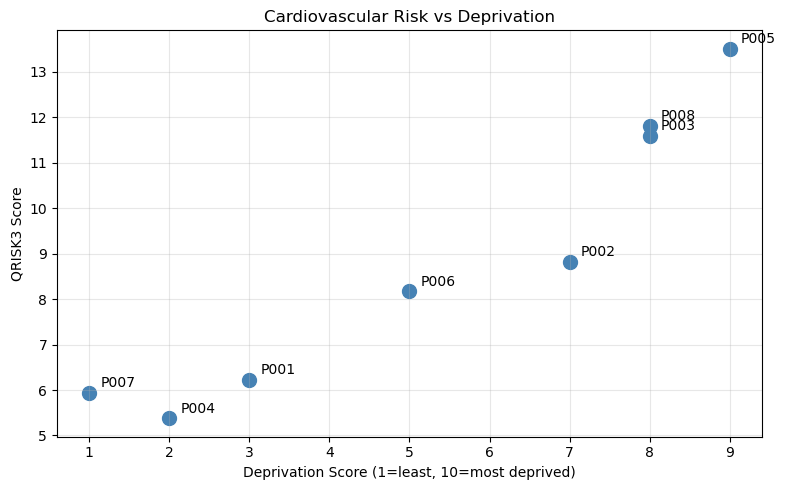

In [21]:
import matplotlib.pyplot as plt

# Scatter plot - deprivation vs qrisk score
plt.figure(figsize=(8, 5))
plt.scatter(df['deprivation'], df['qrisk_score'], color='steelblue', s=100)

# Label each point with patient ID
for i, row in df.iterrows():
    plt.annotate(row['patient_id'], (row['deprivation'], row['qrisk_score']), 
                textcoords="offset points", xytext=(8, 4))

plt.xlabel('Deprivation Score (1=least, 10=most deprived)')
plt.ylabel('QRISK3 Score')
plt.title('Cardiovascular Risk vs Deprivation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

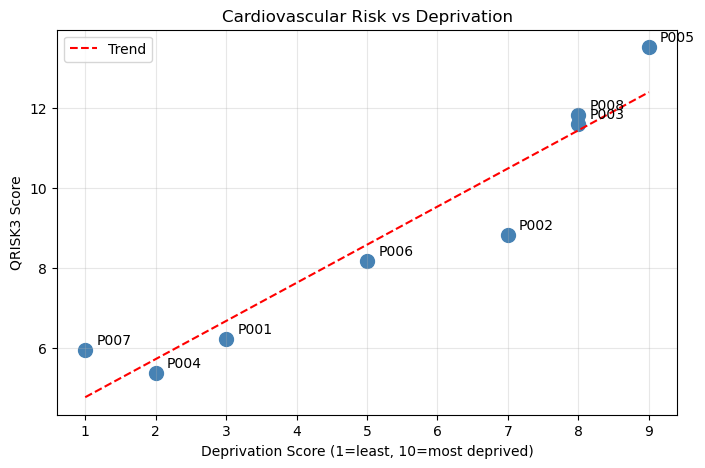

In [22]:
import numpy as np

z = np.polyfit(df['deprivation'], df['qrisk_score'], 1)
p = np.poly1d(z)

plt.figure(figsize=(8, 5))
plt.scatter(df['deprivation'], df['qrisk_score'], color='steelblue', s=100)

for i, row in df.iterrows():
    plt.annotate(row['patient_id'], (row['deprivation'], row['qrisk_score']),
                textcoords="offset points", xytext=(8, 4))

plt.plot(sorted(df['deprivation']), p(sorted(df['deprivation'])), 
         color='red', linestyle='--', label='Trend')

plt.xlabel('Deprivation Score (1=least, 10=most deprived)')
plt.ylabel('QRISK3 Score')
plt.title('Cardiovascular Risk vs Deprivation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Group patients into deprivation quintiles
def deprivation_quintile(score):
    if score <= 2:
        return '1 (least deprived)'
    elif score <= 4:
        return '2'
    elif score <= 6:
        return '3'
    elif score <= 8:
        return '4'
    else:
        return '5 (most deprived)'

df['quintile'] = df['deprivation'].apply(deprivation_quintile)

# Average QRISK3 score per quintile
quintile_risk = df.groupby('quintile')['qrisk_score'].mean()

print(quintile_risk)

quintile
1 (least deprived)     5.659375
2                      6.224286
3                      8.169231
4                     10.744495
5 (most deprived)     13.510000
Name: qrisk_score, dtype: float64


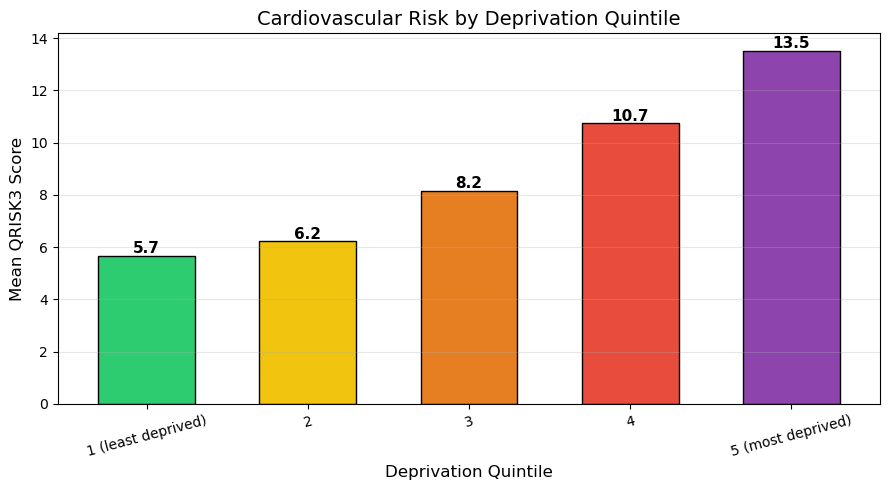

In [24]:
# Bar chart of average QRISK3 score by deprivation quintile
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

quintile_risk.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.6)

ax.set_xlabel('Deprivation Quintile', fontsize=12)
ax.set_ylabel('Mean QRISK3 Score', fontsize=12)
ax.set_title('Cardiovascular Risk by Deprivation Quintile', fontsize=14)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of each bar
for i, v in enumerate(quintile_risk):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

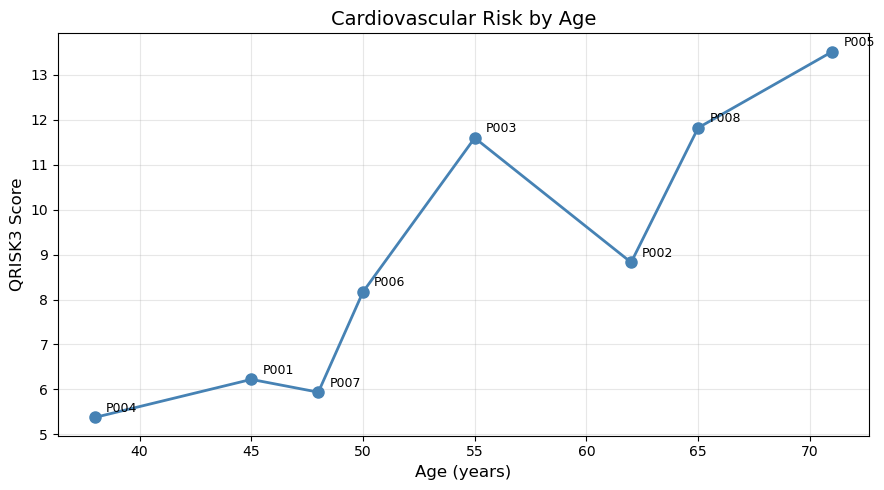

In [25]:
# Sort by age first
df_sorted = df.sort_values('age')

# Line plot of age vs QRISK3 score
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_sorted['age'], df_sorted['qrisk_score'], 
        color='steelblue', linewidth=2, marker='o', markersize=8)

# Label each point with patient ID
for i, row in df_sorted.iterrows():
    ax.annotate(row['patient_id'], 
                (row['age'], row['qrisk_score']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('QRISK3 Score', fontsize=12)
ax.set_title('Cardiovascular Risk by Age', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

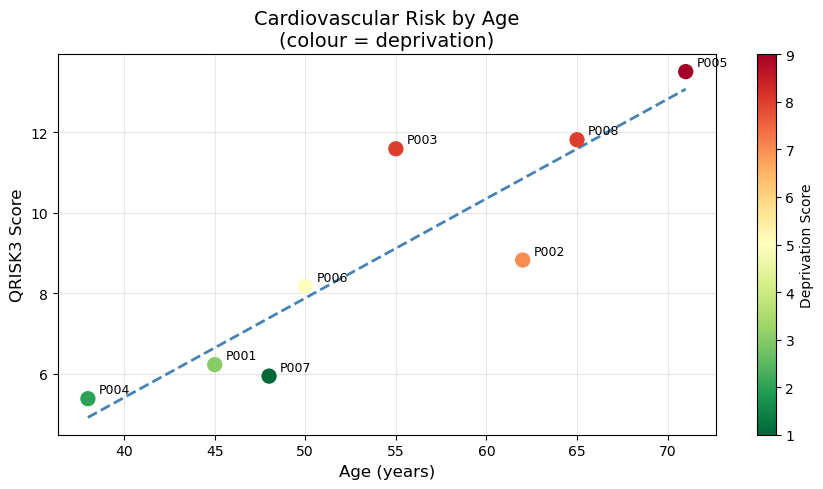

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter points coloured by deprivation
scatter = ax.scatter(df['age'], df['qrisk_score'], 
                     c=df['deprivation'], cmap='RdYlGn_r', 
                     s=100, zorder=5)

# Add trend line
z = np.polyfit(df['age'], df['qrisk_score'], 1)
p = np.poly1d(z)
age_range = range(df['age'].min(), df['age'].max()+1)
ax.plot(age_range, p(age_range), color='steelblue', 
        linestyle='--', linewidth=2, label='Trend')

# Label points
for i, row in df.iterrows():
    ax.annotate(row['patient_id'], (row['age'], row['qrisk_score']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.colorbar(scatter, label='Deprivation Score')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('QRISK3 Score', fontsize=12)
ax.set_title('Cardiovascular Risk by Age\n(colour = deprivation)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

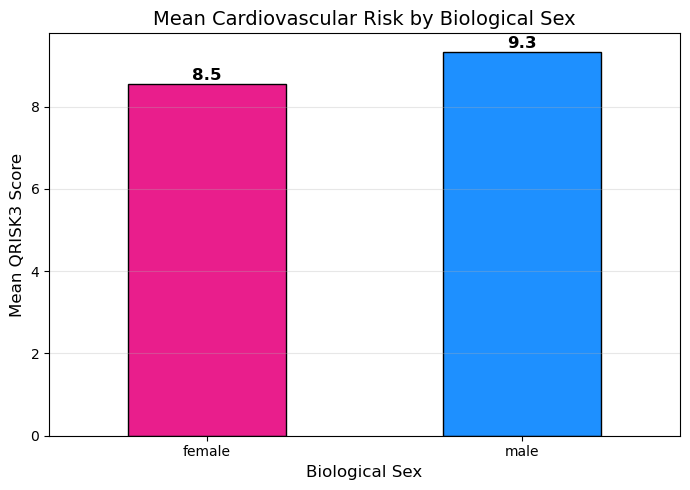

In [27]:
# Average QRISK3 score by sex
sex_risk = df.groupby('sex')['qrisk_score'].mean()

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#e91e8c', '#1e90ff']
sex_risk.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.5)

# Add value labels on top of bars
for i, v in enumerate(sex_risk):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Biological Sex', fontsize=12)
ax.set_ylabel('Mean QRISK3 Score', fontsize=12)
ax.set_title('Mean Cardiovascular Risk by Biological Sex', fontsize=14)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Summary statistics by sex
print(df.groupby('sex')[['age', 'qrisk_score', 'deprivation']].describe().round(2))

         age                                               qrisk_score        \
       count   mean    std   min    25%   50%    75%   max       count  mean   
sex                                                                            
female   4.0  53.75  12.34  38.0  47.00  56.0  62.75  65.0         4.0  8.55   
male     4.0  54.75  11.62  45.0  47.25  51.5  59.00  71.0         4.0  9.32   

        ...               deprivation                                         
        ...    75%    max       count  mean   std  min   25%  50%   75%  max  
sex     ...                                                                   
female  ...   9.57  11.82         4.0  5.50  2.65  2.0  4.25  6.0  7.25  8.0  
male    ...  12.07  13.51         4.0  5.25  3.86  1.0  2.50  5.5  8.25  9.0  

[2 rows x 24 columns]


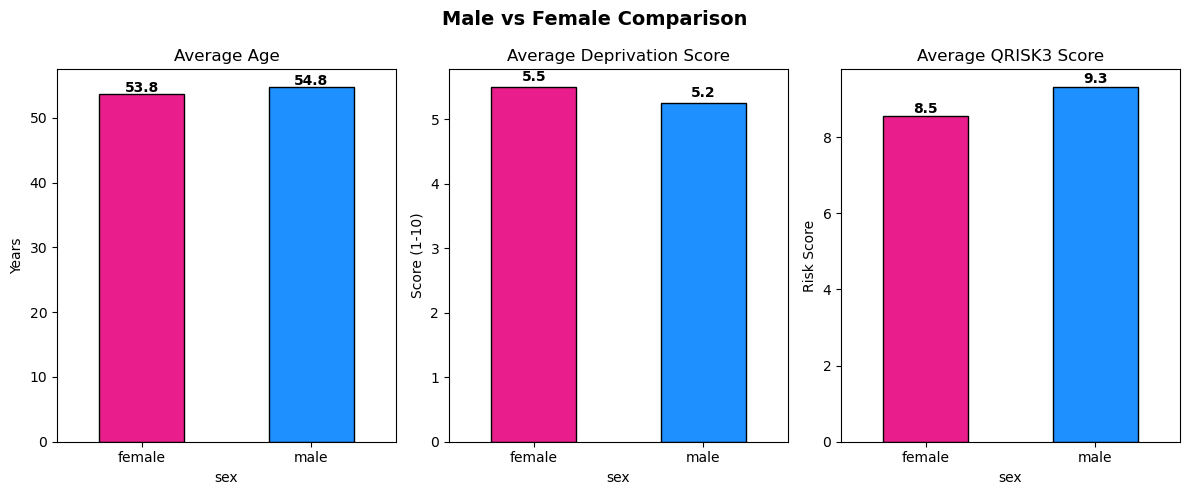

In [29]:
# Side by side comparison - male vs female across multiple variables
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = ['#e91e8c', '#1e90ff']

# Chart 1 - Average age
sex_age = df.groupby('sex')['age'].mean()
sex_age.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Average Age', fontsize=12)
axes[0].set_ylabel('Years')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sex_age):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Chart 2 - Average deprivation
sex_dep = df.groupby('sex')['deprivation'].mean()
sex_dep.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Average Deprivation Score', fontsize=12)
axes[1].set_ylabel('Score (1-10)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(sex_dep):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Chart 3 - Average QRISK3
sex_risk = df.groupby('sex')['qrisk_score'].mean()
sex_risk.plot(kind='bar', ax=axes[2], color=colors, edgecolor='black', width=0.5)
axes[2].set_title('Average QRISK3 Score', fontsize=12)
axes[2].set_ylabel('Risk Score')
axes[2].tick_params(axis='x', rotation=0)
for i, v in enumerate(sex_risk):
    axes[2].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Male vs Female Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
def qrisk3_male(row):
    age_contribution = 0.0651 * row['age']
    systolic_contribution = 0.0178 * row['systolic_bp']
    cholesterol_contribution = 0.1538 * row['chol_ratio']
    deprivation_contribution = 0.0939 * row['deprivation']
    
    smoker = row['smoker']
    if smoker == 'ex':
        f = 0.2693
    elif smoker == 'light':
        f = 0.5176
    elif smoker == 'moderate':
        f = 0.6523
    elif smoker == 'heavy':
        f = 0.7851
    else:
        f = 0.0
    smoking_contribution = f * 1
    
    if row['diabetic'] == 'yes':
        d = 1
    else:
        d = 0
    diabetes_contribution = 0.8104 * d
    
    qrisk_score = (age_contribution + 
                   systolic_contribution + 
                   cholesterol_contribution + 
                   deprivation_contribution + 
                   smoking_contribution + 
                   diabetes_contribution)
    
    return qrisk_score

In [33]:

male_patients = df[df['sex'] == 'male']
male_patients = male_patients.copy()
male_patients['real_qrisk'] = male_patients.apply(qrisk3_male, axis=1)

print(male_patients[['patient_id', 'age', 'deprivation', 'real_qrisk']].round(2))


  patient_id  age  deprivation  real_qrisk
0       P001   45            3        6.06
2       P003   55            8        9.42
4       P005   71            9       10.93
6       P007   48            1        5.90


In [34]:
def qrisk3_female(row):
    age_contribution = 0.0624 * row['age']
    systolic_contribution = 0.0168 * row['systolic_bp']
    cholesterol_contribution = 0.1523 * row['chol_ratio']
    deprivation_contribution = 0.0862 * row['deprivation']
    
    smoker = row['smoker']
    if smoker == 'ex':
        f = 0.2453
    elif smoker == 'light':
        f = 0.4754
    elif smoker == 'moderate':
        f = 0.5765
    elif smoker == 'heavy':
        f = 0.6923
    else:
        f = 0.0
    smoking_contribution = f * 1
    
    if row['diabetic'] == 'yes':
        d = 1
    else:
        d = 0
    diabetes_contribution = 0.7654 * d
    
    qrisk_score = (age_contribution + 
                   systolic_contribution + 
                   cholesterol_contribution + 
                   deprivation_contribution + 
                   smoking_contribution + 
                   diabetes_contribution)
    
    return qrisk_score

In [37]:
female_patients = df[df['sex'] == 'female']
female_patients = female_patients.copy()
female_patients['real_qrisk'] = female_patients.apply(qrisk3_female, axis=1)
print(female_patients[['patient_id', 'age', 'deprivation', 'real_qrisk']].round(2))

  patient_id  age  deprivation  real_qrisk
1       P002   62            7        7.93
3       P004   38            2        4.99
5       P006   50            5        6.94
7       P008   65            8        9.76


In [38]:
all_patients = pd.concat([male_patients, female_patients])
all_patients = all_patients.sort_values('patient_id')
print(all_patients[['patient_id', 'sex', 'age', 'deprivation', 'real_qrisk']].round(2))

  patient_id     sex  age  deprivation  real_qrisk
0       P001    male   45            3        6.06
1       P002  female   62            7        7.93
2       P003    male   55            8        9.42
3       P004  female   38            2        4.99
4       P005    male   71            9       10.93
5       P006  female   50            5        6.94
6       P007    male   48            1        5.90
7       P008  female   65            8        9.76


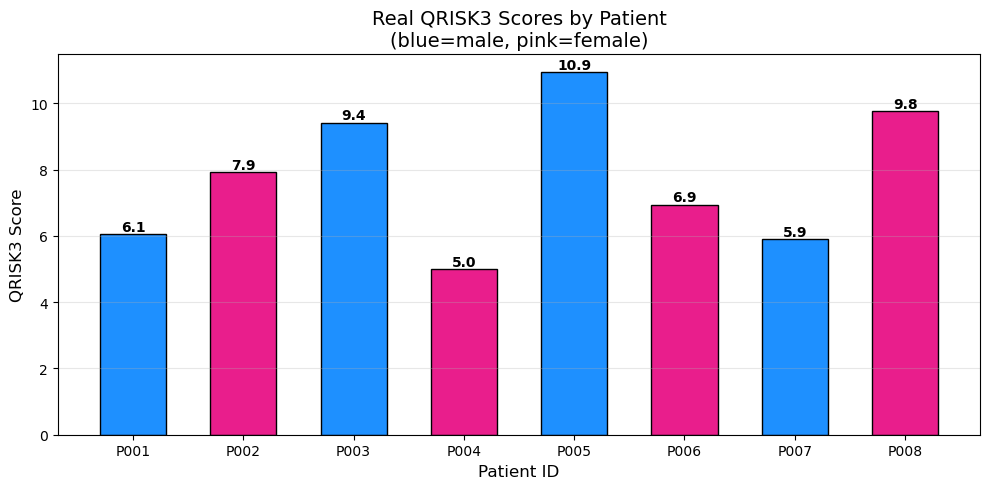

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1e90ff' if sex == 'male' else '#e91e8c' 
          for sex in all_patients['sex']]

bars = ax.bar(all_patients['patient_id'], all_patients['real_qrisk'], 
              color=colors, edgecolor='black', width=0.6)

# Add value labels on top
for bar, val in zip(bars, all_patients['real_qrisk']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, 
            f'{val:.1f}', ha='center', fontweight='bold')

ax.set_xlabel('Patient ID', fontsize=12)
ax.set_ylabel('QRISK3 Score', fontsize=12)
ax.set_title('Real QRISK3 Scores by Patient\n(blue=male, pink=female)', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()